In [10]:
import numpy as np
import pandas as pd
from pathlib import Path 
import os
import shutil

# Import spatialtissuepy
from spatialtissuepy import SpatialTissueData
from spatialtissuepy.io import (
    read_csv,
    write_csv,
    read_json,
    write_json
)

import matplotlib.pyplot as plt
from spatialtissuepy.viz import (
    set_publication_style, plot_spatial_scatter, 
    plot_ripleys_curve, save_figure
)

# Create a temporary directory for examples
import tempfile
temp_dir = tempfile.mkdtemp()
print(f"Working directory: {temp_dir}")

Working directory: /var/folders/99/8rc4_4_n7233rmjmy44dmfbs5531hj/T/tmplrcv5g37


In [11]:
# Create sample data
n_cells = 200

# Generate coordinates
x = np.random.uniform(0, 1000, n_cells)
y = np.random.uniform(0, 1000, n_cells)

# Generate cell types
cell_types = np.random.choice(
    ['CD8_T_cell', 'CD4_T_cell', 'Tumor', 'Macrophage'],
    size=n_cells,
    p=[0.25, 0.20, 0.35, 0.20]
)

# Generate marker data (simulating protein expression)
cd8_expression = np.random.lognormal(mean=2, sigma=1, size=n_cells)
pd1_expression = np.random.lognormal(mean=1.5, sigma=0.8, size=n_cells)
ki67_expression = np.random.uniform(0, 100, n_cells)  # Proliferation marker

# Create DataFrame
df = pd.DataFrame({
    'x': x,
    'y': y,
    'cell_type': cell_types,
    'CD8': cd8_expression,
    'PD1': pd1_expression,
    'Ki67': ki67_expression
})

# Save to CSV
csv_path = Path(temp_dir) / 'tissue_sample.csv'
df.to_csv(csv_path, index=False)

# Display first few rows
print("Sample CSV data:")
print(df.head(10))
print(f"\nSaved to: {csv_path}")

Sample CSV data:
            x           y   cell_type        CD8        PD1       Ki67
0  816.718016  147.775619  Macrophage   0.099478   1.794499  95.871547
1  890.115769  395.848231  CD8_T_cell  11.737036   0.688848  72.706588
2  466.658074  254.761865  Macrophage  15.902639  15.446965  74.569035
3  940.645697  438.762352  CD8_T_cell   8.553171   1.220746  74.516197
4  644.056830  675.608465  CD8_T_cell   6.614216   5.934197   6.227770
5   72.088891  902.888602  CD4_T_cell   2.573897  11.853930   3.893462
6  398.640275  242.759016  CD8_T_cell  14.405893  24.036288  67.643546
7   65.548471  597.274955       Tumor   8.007470   9.290515  85.376763
8  943.264516  978.503371       Tumor  13.962601   3.608228  31.471706
9  833.467107  117.909144       Tumor  13.810386   3.493236  59.222526

Saved to: /var/folders/99/8rc4_4_n7233rmjmy44dmfbs5531hj/T/tmplrcv5g37/tissue_sample.csv


In [12]:
# Load the CSV file
data = read_csv(
    csv_path,
    x_col='x',
    y_col='y',
    celltype_col='cell_type'
)

print(data)
print(f"\nCell types present: {data.cell_types_unique}")
print(f"Marker columns: {list(data.markers.columns) if data.markers is not None else 'None'}")

SpatialTissueData
  Cells: 200
  Dimensions: 2D
  Cell types: 4
  Markers: 3
  Bounds: x=[6.9, 996.5], y=[5.8, 978.5]

Cell types present: ['CD4_T_cell' 'CD8_T_cell' 'Macrophage' 'Tumor']
Marker columns: ['CD8', 'PD1', 'Ki67']


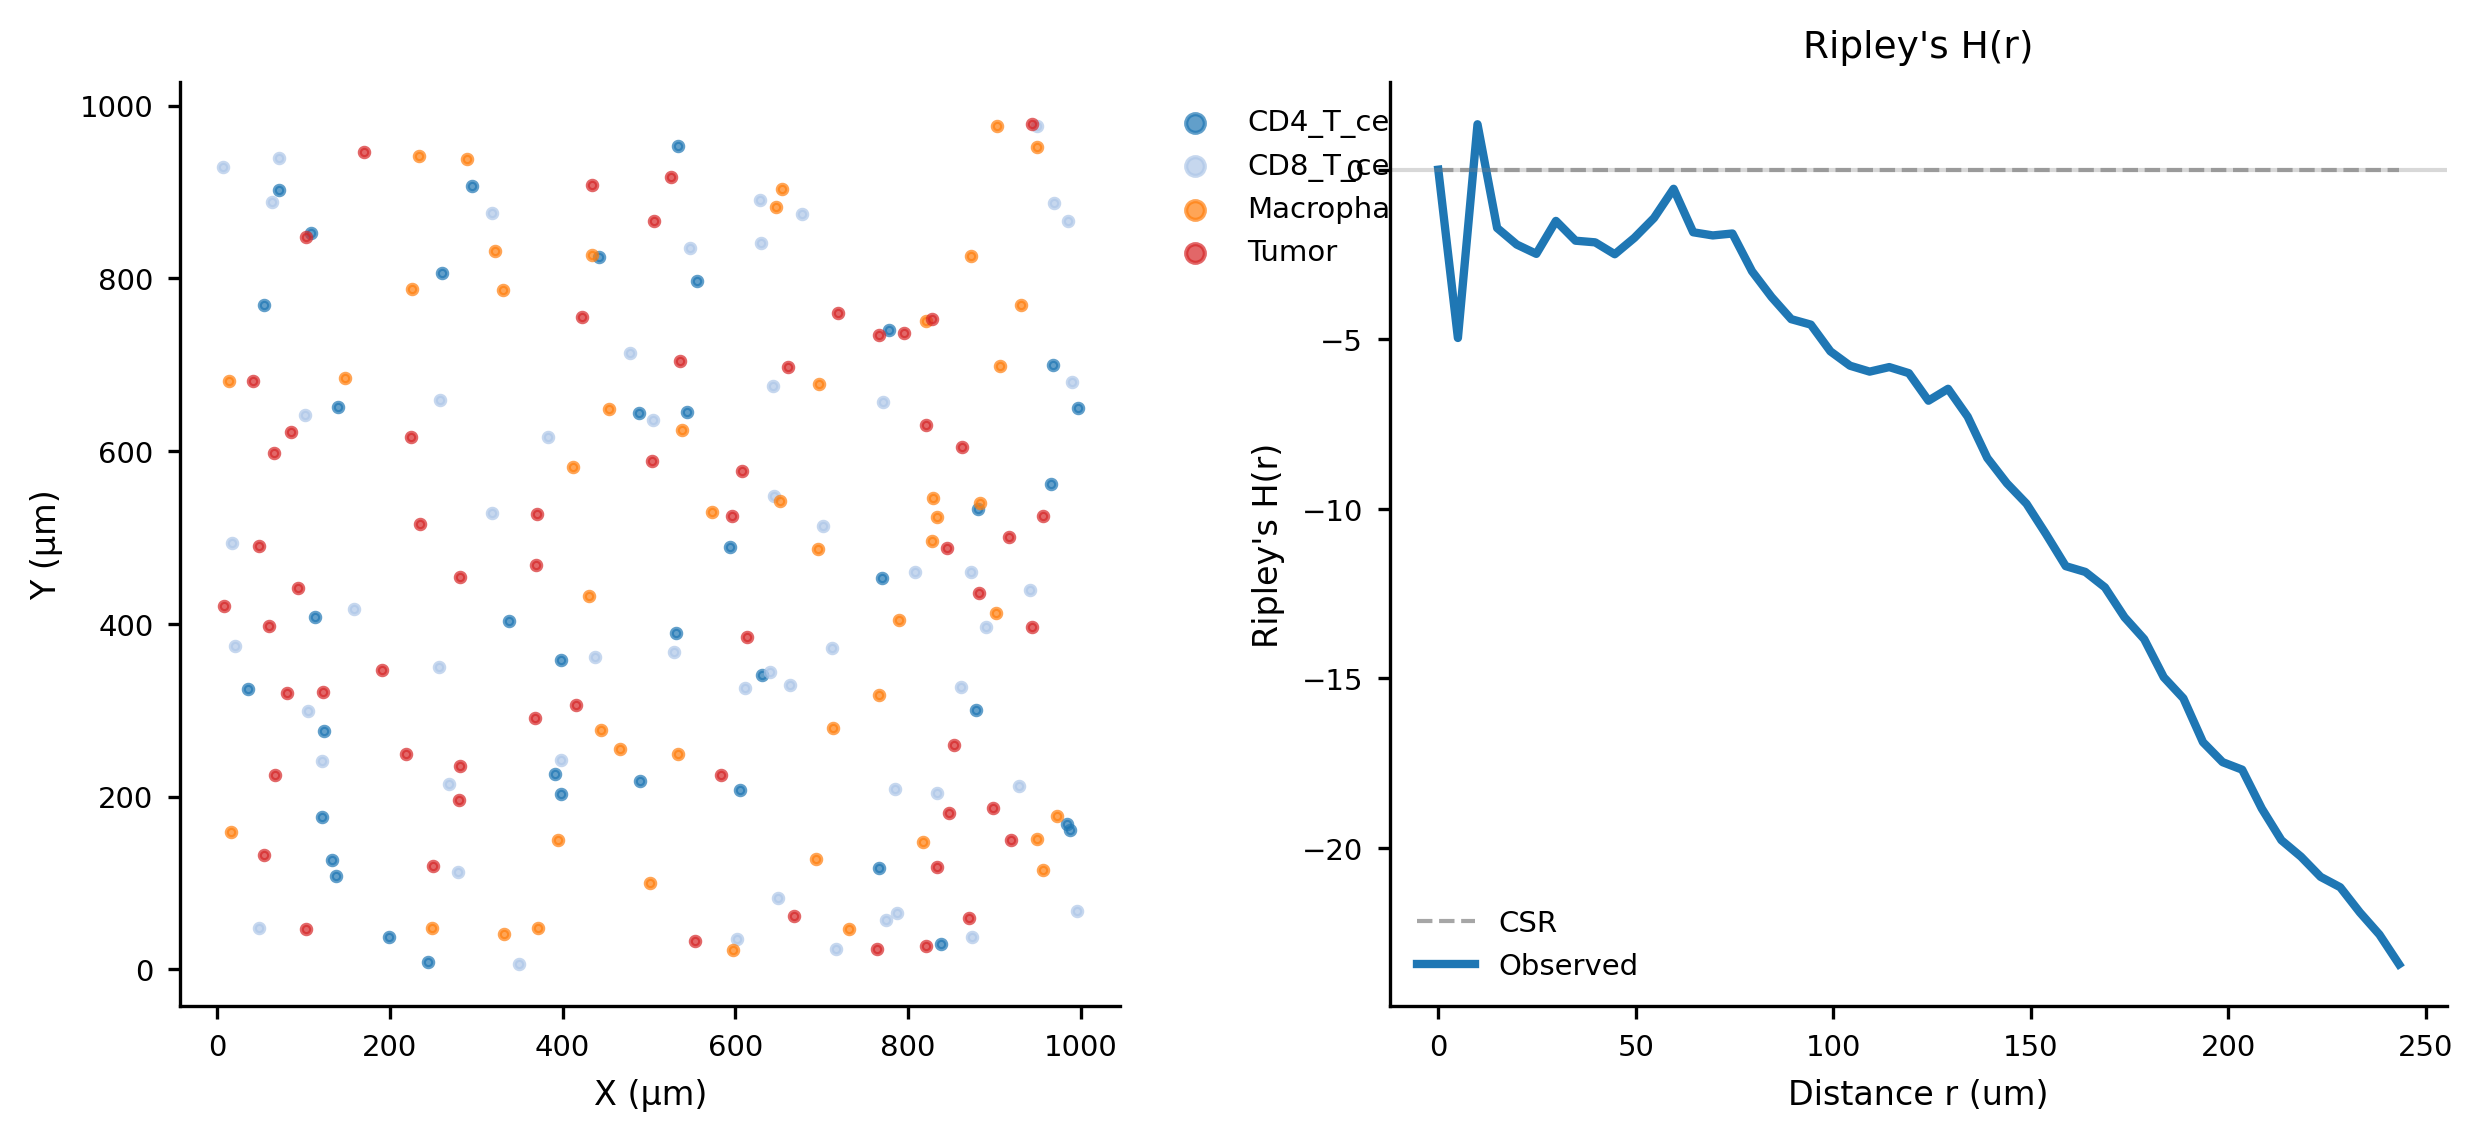

In [13]:
set_publication_style(journal='nature')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_spatial_scatter(data, ax=axes[0])
plot_ripleys_curve(data, ax=axes[1])

save_figure(fig, f'{temp_dir}/figure1', formats=['pdf', 'png'])

In [14]:
# Cleanup: Remove temporary files
shutil.rmtree(temp_dir)
print("Temporary files cleaned up.")

Temporary files cleaned up.
